In [1]:
import cantera as ct
import matplotlib.pyplot as plt

In [2]:
p = ct.one_atm  # pressure
tin_f = 300.0  # fuel inlet temperature
tin_o = 300.0  # oxidizer inlet temperature
mdot_o = 0.72  # kg/m^2/s
mdot_f = 0.24  # kg/m^2/s

comp_o = 'O2:0.21, N2:0.78, AR:0.01'  # air composition
comp_f = 'C2H6:1'  # fuel composition

width = 0.02  # Distance between inlets is 2 cm

loglevel = 1  # amount of diagnostic output (0 to 5)

In [3]:
# Create the gas object used to evaluate all thermodynamic, kinetic, and
# transport properties.
gas = ct.Solution('gri30.yaml')
gas.TP = gas.T, p

# Create an object representing the counterflow flame configuration,
# which consists of a fuel inlet on the left, the flow in the middle,
# and the oxidizer inlet on the right.
f = ct.CounterflowDiffusionFlame(gas, width=width)

# Set the state of the two inlets
f.fuel_inlet.mdot = mdot_f
f.fuel_inlet.X = comp_f
f.fuel_inlet.T = tin_f

f.oxidizer_inlet.mdot = mdot_o
f.oxidizer_inlet.X = comp_o
f.oxidizer_inlet.T = tin_o

# Set the boundary emissivities
f.boundary_emissivities = 0.0, 0.0
# Turn radiation off
f.radiation_enabled = False

f.set_refine_criteria(ratio=4, slope=0.2, curve=0.3, prune=0.04)

In [4]:
f.solve(loglevel, auto=True)

f.show()


************ Solving on 6 point grid with energy equation enabled ************

..............................................................................

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 1.78e-06   log(ss)= 7.095     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 4.561e-05  log(ss)= 5.756     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.0007794  log(ss)= 5.175     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.001754   log(ss)= 4.148     

Attempt Newton solution of steady-state problem.
Newton steady-state solve succeeded.

Problem solved on [6] point grid(s).

..............................................................

In [ ]:
# f.save('diffusion_flame.h5') # ct.hdf_support() must be True to save in HDF5 format https://www.hdfgroup.org/download-hdf5/
# f.save('diffusion_flame.yaml')

f.save('diffusion_flame.csv', basis="mole", overwrite=True)
f.show_stats()
no_rad = f.to_array()


Statistics:

 Grid   Timesteps  Functions      Time  Jacobians      Time
    8           0        808    0.2030         34    0.7560
   13          40        626    0.3270         25    1.1660
   20          20        431    0.3600         13    1.0340
   28          30        418    0.5210         15    1.9020
   40          10        116    0.2200          5    0.9010
   60           0         13    0.0380          2    0.5230
   84           0         10    0.0410          1    0.3800
   95           0          6    0.0270          1    0.4360
   98           0          6    0.0250          1    0.5750


In [6]:

f.radiation_enabled = True
f.solve(loglevel=1, refine_grid=False)
f.show()


..............................................................................

Attempt Newton solution of steady-state problem.
Newton steady-state solve succeeded.

Problem solved on [96] point grid(s).

..............................................................................
grid refinement disabled.


>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> fuel_inlet <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    Mass Flux:         0.24 kg/m^2/s 
    Temperature:        300 K 
    Mass Fractions: 
                    C2H6           1 



>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> flame <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    Pressure:   1.013e+05 Pa

-------------------------------------------------------------------------------
          z    velocity  spread_rate           T      lambda      eField 
-------------------------------------------------------------------------------
          0      0.1965  -2.197e-18         300       -2636           0 
      0.001      0.1856       10.98         300       -2636    

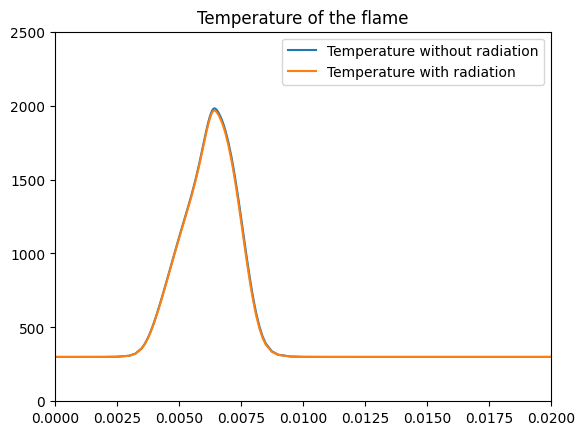

In [7]:
fig, ax = plt.subplots()
ax.plot(no_rad.grid, no_rad.T, label='Temperature without radiation')
plt.plot(f.grid, f.T, label='Temperature with radiation')
ax.set_title('Temperature of the flame')
ax.set(ylim=(0,2500), xlim=(0.000, 0.020))
ax.legend()
fig.savefig('./diffusion_flame.pdf')
plt.show()